In [104]:
import os
import pandas as pd
import numpy as np
import cmath

In [118]:
# pulsars from O1: columns are pulsar, rows are: RA (deg), Dec (deg), Dist (kpc), Grav Freq (kHz)
df = pd.read_csv("o1_data_basic.csv")
print(df['Rows:'], df.columns)

0           RA deg
1          Dec deg
2         Dist kpc
3    Grav Freq kHz
Name: Rows:, dtype: str Index(['Rows:', 'J0023+0923', 'J0024-7204aa', 'J0024-7204ab', 'J0024-7204C',
       'J0024-7204D', 'J0024-7204E', 'J0024-7204F', 'J0024-7204G',
       'J0024-7204H',
       ...
       'J2145-0750', 'J2214+3000', 'J2222-0137', 'J2229+2643', 'J2234+0611',
       'J2235+1506', 'J2241-5236', 'J2302+4442', 'J2317+1439', 'J2322+2057'],
      dtype='str', length=189)


In [78]:
# for expoential:
means = np.geomspace(5*10**-10, 5*10**-8,15)
# if mean < 9.6e-10 or >4.5e-9, generate 10 samples
# else generate 100

In [115]:
def draw_values(mean, num_samples = 1, simulation = True):
    sample_ellipticity = np.random.default_rng().exponential(scale = mean, size=num_samples)
    sample_inclination = np.random.default_rng().uniform(low=-1,high=1, size=num_samples)
    sample_polarization = np.random.default_rng().uniform(low=0,high=np.pi / 2, size=num_samples)
    sample_phase = np.random.default_rng().uniform(low = 0, high=np.pi, size=num_samples)

    samples = {'ellipticity': sample_ellipticity,
    'inclination': sample_inclination,
    'polarization': sample_polarization,
    'phase': sample_phase
    }

    if simulation:
        samples['sidereal_phase'] = np.random.default_rng().uniform(low=0, high=2*np.pi,size=num_samples)
    return samples

In [ ]:
# can iterate using: for column_name, series in df.items()
# or get single column using: df.iloc[:,column_number]

In [101]:
def eval_hstat(distance, ellipticity, frequency):
    h0=4.2*10**-24 * (frequency**2 / distance) * (ellipticity / 10**-6)
    return h0

In [127]:
minutes = 525600
dt = 30
time_time_series = np.arange(0,minutes,dt)
def generate_pulsar_time_series(h0, inclination,polarization,phase,ra,dec,sidereal_phase, time_time_series):
    # ---------------
    # generating complex time series of pulsar signal
    # need to figure out how I shold combine data (coherently), and where i should separate it for processing stages
    # also add noise
    # as of now, returns time series' for single pulsar in lone ensemble for LIGO livingston and hanford

    earth_rot = 7.2921151467 * 10e-5* 180 / np.pi
    # since this is simulation, i'll draw the sidereal phase from a distrubution. 
    

    def complex_time_series(time,earth_rot,lat,orien,ang):
        # have to add noise to this output
        
        def orientation_term():
            return ra - sidereal_phase - earth_rot * time * 60
        
        def a():
            return 1 / 16 * np.sin(2*orien) * (3 - np.cos(2*lat)) * (3-np.cos(2*dec)) * np.cos(orientation_term()) - 1 / 4 * np.cos(2*orien)*np.sin(lat)*(3-np.cos(2*dec))*np.sin(2*orientation_term()) + 1/4 * np.sin(2*orien)*np.sin(2*lat)*np.sin(2*dec)*np.cos(orientation_term())-1/2*np.cos(2*orien)*np.cos(lat)*np.sin(2*dec)*np.sin(orientation_term())+3/4*np.sin(2*orien)*np.cos(lat)**2*np.cos(dec)**2
        
        def b():
            return np.cos(2*orien)*np.sin(lat)*np.sin(dec)*np.cos(2*orientation_term())+1/4*np.sin(2*orien)*(3-np.cos(2*lat))*np.sin(dec)*np.sin(2*orientation_term())+np.cos(2*orien)*np.cos(lat)*np.cos(dec)*np.cos(orientation_term())+1/2*np.sin(2*orien)*np.sin(2*lat)*np.cos(dec)*np.sin(orientation_term())
        
        def Fplus():
            return np.sin(ang)*(a()*np.cos(2*polarization)+b()*np.sin(2*polarization))
        
        def Fcross():
            return np.sin(ang)*(b()*np.cos(2*polarization)-a()*np.sin(2*polarization))

        return 1/4*Fplus()*h0*(1+inclination**2)*np.exp(1j*phase) - (1j/2)*Fcross()*h0*inclination*np.exp(1j*phase)



    # LIGO Hanford:
    h_lat = 46.45
    h_orien = 171.8
    h_ang = 90

    hanford_series = complex_time_series(time_time_series, earth_rot, h_lat, h_orien, h_ang)


    # LIGO Livingston
    l_lat = 30.56
    l_orien = 243.0
    l_ang = 90

    livingston_series = complex_time_series(time_time_series, earth_rot, l_lat, l_orien, l_ang)

    return hanford_series, livingston_series



In [128]:
# random example
# choose one exponential distrubtion
mean = means[5]

# draw samples from our distributions
values = draw_values(mean, num_samples=1, simulation = True)
ellipticity = values['ellipticity']
inclination = values['inclination']
polarization = values['polarization']
phase = values['phase']
sidereal_phase = values['sidereal_phase']

# pick star
sample_star = df.iloc[:,1]
ra = sample_star[0]
dec = sample_star[1]
distance = sample_star[2]
freq = sample_star[3]

# evaluate h0
h0 = eval_hstat(distance, ellipticity, freq)

# create complex time series

complex_time_series = generate_pulsar_time_series(h0, inclination, polarization, phase, ra, dec, sidereal_phase, time_time_series)

In [ ]:
hanford = complex_time_series[0]
livingston = complex_time_series[1]


In [132]:
import matplotlib.pyplot as plt

(0.0, 50000.0)

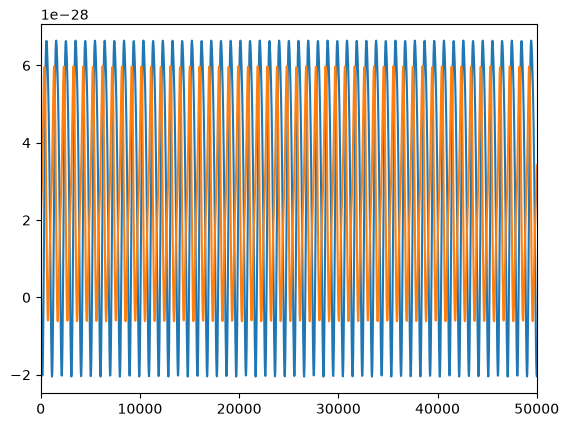

In [136]:
plt.plot(time_time_series, hanford.real)
plt.plot(time_time_series, hanford.imag)
plt.xlim(0,50000)